In [1]:
import pandas as pd
import os
from tqdm import tqdm
from glob import glob
from scipy.stats import spearmanr
import numpy as np
import matplotlib.pyplot as plt

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.0
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
metadata_path = "../../data/Figure5_CASP_ProteinGym/ProteinGym/DMS_substitutions.mmseqs_filtered.reannotated.csv"
metadata_df = pd.read_csv(metadata_path)
metadata_df = metadata_df.set_index('DMS_id')
metadata_df['MSA_Neff_L_category'] = metadata_df['MSA_Neff_L_category'].map(lambda x: str(x).title())

baseline_df = pd.read_csv("../../data/Figure5_CASP_ProteinGym/ProteinGym/SBS_model_spearman_rho.csv", index_col=0)
results_files_l = glob("results/proteingym_uniref_og/*.csv")
baseline_df.loc['MSA Pairformer'] = np.nan
for file in tqdm(results_files_l):
    exp_name = os.path.basename(file).split('.csv')[0]
    res_df = pd.read_csv(file)
    rho, pval = spearmanr(res_df['MSA_model'], res_df['DMS_score'])
    baseline_df.loc["MSA Pairformer", exp_name] = rho

results_files_l = glob("results/proteingym_logan/*.csv")
baseline_df.loc['MSA Pairformer (Logan)'] = np.nan
for file in tqdm(results_files_l):
    exp_name = os.path.basename(file).split('.logan.csv')[0]
    res_df = pd.read_csv(file)
    rho, pval = spearmanr(res_df['mutation_score'], res_df['DMS_score'])
    baseline_df.loc["MSA Pairformer (Logan)", exp_name] = rho


baseline_df = baseline_df.T
baseline_df['coarse_selection_type'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'coarse_selection_type'])
baseline_df['MSA_Neff_L_category'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'MSA_Neff_L_category'])
baseline_df['taxon'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'taxon'])
baseline_df['UniProt_ID'] = baseline_df.index.map(lambda x: metadata_df.loc[x, 'UniProt_ID'])


  0%|          | 0/217 [00:00<?, ?it/s]

100%|██████████| 217/217 [00:08<00:00, 24.83it/s]


In [12]:
copy_baseline_df = baseline_df.copy()
# For each coarse_selection_type, first average within UniProt_ID, then average across UniProt_ID per type.

# Get all the columns that are numeric and relevant
value_columns = [col for col in copy_baseline_df.columns if col not in ['coarse_selection_type', 'MSA_Neff_L_category', 'taxon', 'UniProt_ID'] and copy_baseline_df[col].dtype in ['float64', 'float32', 'int64', 'int32']]

# First, group by ['coarse_selection_type', 'UniProt_ID'] and average
grouped_uni = copy_baseline_df.groupby(['coarse_selection_type', 'UniProt_ID'])[value_columns].mean()

# Next, for each coarse_selection_type, average across all UniProt_ID
avg_by_coarse = grouped_uni.groupby('coarse_selection_type').mean()

methods_l = ['MSA Pairformer', 'MSA Pairformer (Logan)', 'MSA_Transformer_ensemble', 'MSA_Transformer_single', 'ESMC-600M', 'ESMC-300M', 'ESM2_15B', 'ESM2_3B', 'ESM2_150M', 'ESM2_650M']
model_averages_s = avg_by_coarse[methods_l].sort_values(by='ESMC-600M', ascending=False).mean().sort_values(ascending=False)
mean_spearman_s = avg_by_coarse.mean(axis=0)
avg_by_coarse[methods_l].loc[['Activity', 'OrganismalFitness', 'Binding', 'Expression', 'Stability']][methods_l].T

coarse_selection_type,Activity,OrganismalFitness,Binding,Expression,Stability
MSA Pairformer,0.485735,0.451423,0.361730,0.437756,0.506818
MSA Pairformer (Logan),0.498227,0.461789,0.357230,0.447078,0.498772
MSA_Transformer_ensemble,0.473031,0.418766,0.328755,0.445991,0.492063
MSA_Transformer_single,0.454865,0.412018,0.311446,0.429270,0.475263
ESMC-600M,0.422879,0.361804,0.293606,0.419958,0.527707
ESMC-300M,0.422567,0.359965,0.315159,0.407609,0.525709
ESM2_15B,0.404630,0.387376,0.316935,0.405261,0.487545
ESM2_3B,0.417068,0.378371,0.321186,0.402855,0.509062
ESM2_150M,0.391363,0.304680,0.326123,0.401919,0.509920
ESM2_650M,0.425383,0.368352,0.336602,0.415110,0.523273


In [13]:
copy_baseline_df = baseline_df.copy()
# For each coarse_selection_type, first average within UniProt_ID, then average across UniProt_ID per type.

# Get all the columns that are numeric and relevant
value_columns = [col for col in copy_baseline_df.columns if col not in ['coarse_selection_type', 'MSA_Neff_L_category', 'taxon', 'UniProt_ID'] and copy_baseline_df[col].dtype in ['float64', 'float32', 'int64', 'int32']]

# First, group by ['taxon', 'UniProt_ID'] and average
grouped_uni = copy_baseline_df.groupby(['taxon', 'UniProt_ID'])[value_columns].mean()

# Next, for each taxon, average across all UniProt_ID
avg_by_taxon = grouped_uni.groupby('taxon').mean()

model_averages_s = avg_by_taxon[methods_l].sort_values(by='ESMC-600M', ascending=False).mean().sort_values(ascending=False)
avg_by_taxon[methods_l].loc[['Human', 'Eukaryote', 'Prokaryote', 'Virus']][methods_l].T

taxon,Human,Eukaryote,Prokaryote,Virus
MSA Pairformer,0.456260,0.530322,0.454648,0.470743
MSA Pairformer (Logan),0.454583,0.527119,0.463567,0.486657
MSA_Transformer_ensemble,0.439008,0.515506,0.446125,0.421128
MSA_Transformer_single,0.429578,0.501028,0.425744,0.405885
ESMC-600M,0.462122,0.480716,0.458551,0.240586
ESMC-300M,0.467966,0.480625,0.441433,0.241761
ESM2_15B,0.431640,0.467183,0.436241,0.332799
ESM2_3B,0.442195,0.476684,0.458472,0.294317
ESM2_150M,0.450156,0.474465,0.398267,0.157142
ESM2_650M,0.457167,0.486313,0.457479,0.261076


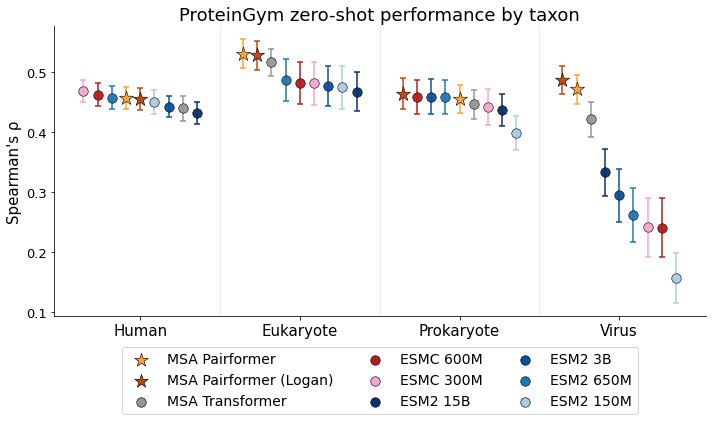

In [29]:
# Summarize by taxon
# Two-step averaging (consistent with the cell above): first average within
# UniProt_ID, then summarize across UniProt_ID per taxon. Standard error is
# taken across UniProt_IDs within each taxon.
copy_baseline_df = baseline_df.copy()
value_columns = [col for col in copy_baseline_df.columns
                 if col not in ['coarse_selection_type', 'MSA_Neff_L_category', 'taxon', 'UniProt_ID']
                 and copy_baseline_df[col].dtype in ['float64', 'float32', 'int64', 'int32']]

# First average within UniProt_ID (per taxon), then summarize across UniProt_IDs
grouped_uni = copy_baseline_df.groupby(['taxon', 'UniProt_ID'])[value_columns].mean()
taxon_means = grouped_uni.groupby('taxon').mean()
taxon_se = grouped_uni.groupby('taxon').sem()
# Do not compute or use any "Avg." (overall average across all UniProt_IDs or taxa)

# Models to display: MSA Pairformer, MSA Pairformer (Logan), MSA Transformer, and all ESM models
logan_col = next((c for c in ['MSA Pairformer (Logan)', 'MSA Pairformer Logan'] if c in taxon_means.columns), None)
plot_methods = ['MSA Pairformer', logan_col, 'MSA_Transformer_ensemble',
                'ESMC-600M', 'ESMC-300M', 'ESM2_15B', 'ESM2_3B', 'ESM2_650M', 'ESM2_150M']
plot_methods = [m for m in plot_methods if m is not None and m in taxon_means.columns]

# Pretty labels for the legend
label_map = {
    'MSA Pairformer': 'MSA Pairformer',
    'MSA Pairformer (Logan)': 'MSA Pairformer (Logan)',
    'MSA Pairformer Logan': 'MSA Pairformer (Logan)',
    'MSA_Transformer_ensemble': 'MSA Transformer',
    'ESMC-600M': 'ESMC 600M', 'ESMC-300M': 'ESMC 300M',
    'ESM2_15B': 'ESM2 15B', 'ESM2_3B': 'ESM2 3B',
    'ESM2_650M': 'ESM2 650M', 'ESM2_150M': 'ESM2 150M',
}

# Only show taxa, no overall "Avg."
taxon_order = [t for t in ['Human', 'Eukaryote', 'Prokaryote', 'Virus'] if t in taxon_means.index]

from matplotlib.colors import ListedColormap

# Define custom orange shades: lighter orange for MSA Pairformer, darker/more saturated orange with higher contrast for MSA Pairformer (Logan)
pairformer_oranges = [
    "#FFA134",  # lighter orange (MSA Pairformer)
    "#C1440E",  # much darker, high-contrast orange (MSA Pairformer (Logan))
]

# Use clearly distinguished blues for the four ESM2 models
# The below are colorblind-friendly and visually distinct
esm2_blue_map = {
    'ESM2_150M': "#A6CEE3",  # sky blue
    'ESM2_650M': "#1F78B4",  # strong blue
    'ESM2_3B':   "#08519C",  # dark blue
    'ESM2_15B':  "#08306B",  # very dark blue
}

# For ESMC models, use pink for ESMC-300M and clearly distinguishable dark red for ESMC-600M
esmc_colors = [
    "#F7A5D1",  # ESMC 300M - lighter shade of pink
    "#B71C1C",  # ESMC 600M - deep red (darker)
]

# Build mapping from model to color
model_color = {}
# MSA Pairformer
pf_methods = ['MSA Pairformer', logan_col]
pf_methods = [m for m in pf_methods if m is not None and m in plot_methods]
for i, m in enumerate(pf_methods):
    model_color[m] = pairformer_oranges[i % len(pairformer_oranges)]
# MSA Transformer
if 'MSA_Transformer_ensemble' in plot_methods:
    model_color['MSA_Transformer_ensemble'] = "#979797"  # medium gray

# ESM2 models: use the highly distinguished blues above
esm2_all = ['ESM2_150M', 'ESM2_650M', 'ESM2_3B', 'ESM2_15B']
for esm2 in esm2_all:
    if esm2 in plot_methods:
        model_color[esm2] = esm2_blue_map[esm2]
# ESMC models: pink and deep red
esmc_all = ['ESMC-300M', 'ESMC-600M']
for i, c in enumerate(esmc_all):
    if c in plot_methods:
        model_color[c] = esmc_colors[i % len(esmc_colors)]

# Highlight the main two
highlight = {'MSA Pairformer', logan_col}

fig, ax = plt.subplots(figsize=(10, 6))
num_models = len(plot_methods)
point_spacing = 0.8 / num_models
indices = np.arange(len(taxon_order))

for i, taxon in enumerate(taxon_order):
    row = taxon_means.loc[taxon]
    err = taxon_se.loc[taxon]
    # Sort models by performance (descending) within this taxon for readability
    sorted_methods = sorted(plot_methods, key=lambda m: row[m], reverse=True)
    for j, m in enumerate(sorted_methods):
        position = indices[i] + (j - num_models / 2 + 0.5) * point_spacing
        ax.errorbar(position, row[m], yerr=err[m], color=model_color[m],
                    capsize=3, elinewidth=1.5, capthick=1.5, zorder=2)
        is_hl = m in highlight
        ax.scatter(position, row[m], color=model_color[m],
                   s=220 if is_hl else 90, marker='*' if is_hl else 'o',
                   alpha=0.95, edgecolor='black', linewidth=0.6, zorder=3)

# Legend (proxy artists), MSA models first
for m in plot_methods:
    is_hl = m in highlight
    ax.scatter([], [], color=model_color[m], s=200 if is_hl else 90,
               marker='*' if is_hl else 'o', edgecolor='black', linewidth=0.6,
               label=label_map.get(m, m))
handles, labels = ax.get_legend_handles_labels()
front = [l for l in labels if l in ('MSA Pairformer', 'MSA Pairformer (Logan)', 'MSA Transformer')]
order = front + [l for l in labels if l not in front]
hl_map = dict(zip(labels, handles))
ax.legend([hl_map[l] for l in order], order, fontsize=14, loc='upper center',
          bbox_to_anchor=(0.5, -0.08), ncol=3)

ax.set_title("ProteinGym zero-shot performance by taxon", fontsize=18)
ax.set_ylabel("Spearman's ρ", fontsize=15)
ax.set_xticks(indices)
ax.set_xticklabels(taxon_order, fontsize=15)
ax.tick_params(axis='y', labelsize=13)
ax.grid(False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
for x in indices[:-1] + 0.5:
    ax.axvline(x, color='grey', alpha=0.15, linewidth=1)

plt.tight_layout()
plt.show()

In [57]:
# Load CASP15 results
results_df = pd.read_csv("results/CASP15_contact_predictions.tsv", index_col=0, sep="\t")
# Subset for targets predicted by all methods
results_df = results_df.dropna(axis=0)
print(f"Number of targets predicted by all methods: {len(results_df)}")
long_pl_s = results_df[[c for c in results_df.columns if "long" in c]].median(axis=0)
long_pl_s.index = long_pl_s.index.map(lambda x: x.replace(" long", ""))
long_pl_d = long_pl_s.to_dict()
long_pl_s

Number of targets predicted by all methods: 45


MSA Pairformer             0.660274
MSA Pairformer (Logan)     0.706849
MSA Transformer            0.500000
MSA Transformer (Logan)    0.552734
ESM2 150M                  0.376682
ESM2 300M                  0.487805
ESM2 650M                  0.467391
ESM2 3B                    0.487805
ESM2 15B                   0.501465
ESMC 300M                  0.458984
ESMC 600M                  0.482422
dtype: float64

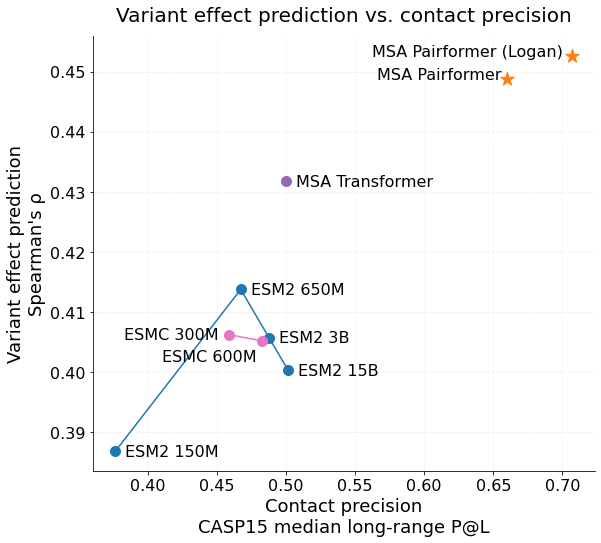

In [59]:
f, ax = plt.subplots(1, 1, figsize=(9, 8))
# Plot ESM2 models
esm_model_names_l = ['ESM2 150M', 'ESM2 650M', 'ESM2 3B', 'ESM2 15B']
# Plot ESM2 models with labels
esm_y = [mean_spearman_s.loc[m.replace(" ", "_")] for m in esm_model_names_l]
esm_y_casp15 = [long_pl_d[m] for m in esm_model_names_l]
ax.plot(esm_y_casp15, esm_y, 'o-', markersize=10)
# Add labels for each point
for i, model_name in enumerate(esm_model_names_l):
    ax.annotate(
        model_name.replace("_", " "), (esm_y_casp15[i], esm_y[i]), 
        textcoords="offset points", 
        xytext=(10, -5), 
        ha='left',
        size=16
    )
# Plot ESM2 models
esm_model_names_l = ['ESMC 300M', 'ESMC 600M']
# Plot ESM2 models with labels
esm_y = [mean_spearman_s.loc[m.replace(" ", "-")] for m in esm_model_names_l]
esm_y_casp15 = [long_pl_d[m] for m in esm_model_names_l]
ax.plot(esm_y_casp15, esm_y, 'o-', markersize=10, color="C6")
# Add labels for each point
# for i, model_name in enumerate(esm_model_names_l):
ax.annotate(
    "ESMC 300M", (esm_y_casp15[0], esm_y[0]), 
    textcoords="offset points", 
    xytext=(-105, -5), 
    ha='left',
    size=16,
)
ax.annotate(
    "ESMC 600M", (esm_y_casp15[1], esm_y[1]), 
    textcoords="offset points", 
    xytext=(-100, -20), 
    ha='left',
    size=16,
)
# Plot MSA Transformer
ax.scatter(long_pl_d["MSA Transformer"], mean_spearman_s.loc["MSA_Transformer_ensemble"], color="C4", marker="o", s=100)
ax.annotate(
    "MSA Transformer", (long_pl_d["MSA Transformer"], mean_spearman_s.loc["MSA_Transformer_ensemble"]), 
    textcoords="offset points", 
    xytext=(10, -5), 
    ha='left',
    size=16
)
# Plot MSA pairformer
ax.scatter(long_pl_d["MSA Pairformer"], mean_spearman_s.loc["MSA Pairformer"], color="C1", marker="*", s=200)
ax.annotate(
    "MSA Pairformer",
    (long_pl_d["MSA Pairformer"], mean_spearman_s.loc["MSA Pairformer"]), 
    textcoords="offset points", 
    xytext=(-130, 0), 
    ha='left',
    size=16
)
# Plot MSA pairformer Logan
ax.scatter(long_pl_d["MSA Pairformer (Logan)"], mean_spearman_s.loc["MSA Pairformer (Logan)"], color="C1", marker="*", s=200)
ax.annotate(
    "MSA Pairformer (Logan)",
    (long_pl_d["MSA Pairformer (Logan)"], mean_spearman_s.loc["MSA Pairformer (Logan)"]), 
    textcoords="offset points", 
    xytext=(-200, 0), 
    ha='left',
    size=16
)
ax.set_ylabel("Variant effect prediction\nSpearman's ρ", size=18)
ax.set_xlabel("Contact precision\nCASP15 median long-range P@L", size=18)
ax.set_title("Variant effect prediction vs. contact precision", size=20, y=1.02)
# Increase tick label size
ax.tick_params(axis='y', labelsize=16)
ax.tick_params(axis='x', labelsize=16)
# Format y-axis tick labels to show only hundredths place
ax.yaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
ax.xaxis.set_major_formatter(plt.FormatStrFormatter('%.2f'))
# Add grid with fainter lines
ax.grid(True, alpha=0.15, linestyle='--')
# Remove top and right spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)